# Analysis: Learning More About Matched Individuals

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [142]:
loan_office_certificates = pd.read_csv("loan_office_certificates_cleaned.csv")
post_1790 = pd.read_csv("post_1790.csv")

In [143]:
loan_office_certificates["raw_name_state"] = loan_office_certificates["raw_name"] + "||" + loan_office_certificates["state"]

In [144]:
loan_office_certificates["raw_name_state"].head()

0     JOSHUA WENTWORTH||NH
1    CHARLES TREADWELL||NH
2     STEPHEN CLEVERLY||NH
3       DAVID GRIFFITH||NH
4       JOHN MANSFIELD||NH
Name: raw_name_state, dtype: object

## Percent of Total Debt Held By Matches

In [145]:
# find total value of all debt certificates
total = loan_office_certificates["Face Value"].sum()
print(total) 

56419829


In [146]:
# find total owned by matched names
total_matched = loan_office_certificates[loan_office_certificates["matched_status"]]["Face Value"].sum()
print(total_matched)

7069910


In [147]:
# calculate percentage 
print((total_matched / total) * 100)

12.530895830967514


In [148]:
# what percentage of debtholders did the matches make up
total_unique_names = loan_office_certificates["raw_name_state"].nunique()
total_unique_matched_names = loan_office_certificates[loan_office_certificates["matched_status"]]["raw_name_state"].nunique()
print("total unique names: " + str(total_unique_names))
print("total unique matched names: " + str(total_unique_matched_names))

print((total_unique_matched_names / total_unique_names) * 100)

total unique names: 18120
total unique matched names: 782
4.315673289183223


## Average Amoung Held By Matches VS Non-Matches

In [149]:
# filter only for matched rows
matched_df = loan_office_certificates[loan_office_certificates["matched_status"]]
# group rows by individuals, summing their certificates
grouped_matched = matched_df.groupby("raw_name_state")["Face Value"].sum()

In [150]:
# calculate average
average_matched = grouped_matched.mean()
print(average_matched)

9037.480818414322


In [151]:
# filter only for non-matched rows
nonmatched_df = loan_office_certificates[~loan_office_certificates["matched_status"]]
print(str(nonmatched_df.shape[0]) + " total rows")

grouped_nonmatched = nonmatched_df.groupby("raw_name_state")["Face Value"].sum()

69679 total rows


In [152]:
# calculate average
average_nonmatched = grouped_nonmatched.mean()
print(average_nonmatched)

2845.819529357481


In [153]:
average_matched - average_nonmatched

np.float64(6191.661289056841)

## Comparing Holdings Before and After 1790

In [154]:
# create reconcile id column that corresponds to "A[column + 2]:Z[column + 2]"
post_1790["recon_id"] = post_1790["Column"].apply(lambda x: f"A{x + 2}:Z{x + 2}")
post_1790["recon_id"].head()

0    A2:Z2
1    A3:Z3
2    A4:Z4
3    A5:Z5
4    A6:Z6
Name: recon_id, dtype: object

In [155]:
# get a list of reconcile ids from matched names from pre-1790 dataset
matched_recon_ids = loan_office_certificates.loc[loan_office_certificates["matched_status"], "recon_id"].dropna().unique()
print("example: " + matched_recon_ids[0]) # expect: A3339:Z3339

example: A3339:Z3339


In [156]:
# create a matched_status column in post-1790 dataset
post_1790["matched_status"] = post_1790["recon_id"].isin(matched_recon_ids) 
count = len(post_1790[post_1790["matched_status"] == True])
print(count)

782


In [157]:
# see how many names were missed
matched_names_set = set(loan_office_certificates.loc[loan_office_certificates["matched_status"], "recon_id"].dropna().unique())
post_names_set = set(post_1790["recon_id"].unique())

# get a set of all missed names
missing = matched_names_set - post_names_set
print(f"{len(missing)} names from pre-1790 matched list not found in post-1790:")
print(sorted(missing))

0 names from pre-1790 matched list not found in post-1790:
[]


In [158]:
# get total owned by matches in pre-1790 dataset
total_matched_pre = loan_office_certificates.loc[loan_office_certificates["matched_status"], "Face Value"].sum()
# get total owned by matches in post-1790 dataset
total_matched_post = post_1790.loc[post_1790["matched_status"], "final_total_adj"].sum()
print(f"total owned by matches (pre-1790): ${total_matched_pre:.2f}")
print(f"total owned by matches (post-1790): ${total_matched_post:.2f}")

total owned by matches (pre-1790): $7069910.00
total owned by matches (post-1790): $1955405.04


In [159]:
post_1790["raw_name_state"] = post_1790["Group Name"].str.upper() + "||" + post_1790["state"]
post_1790.head()

,Column,Group Name,state,Group County,Group Town,Group Name Type,Group Match Index,Group Match Url,Full Search Name,assets,...,6p_def_total,unpaid_interest,6p_total_adj,6p_def_total_adj,unpaid_interest_adj,final_total,final_total_adj,recon_id,matched_status,raw_name_state
0,0,Desdeily,NY,NaN,NaN,state,NaN,NaN,Desdeily,"NY_1947_1 : 0.0, 0.0, 5140.86",...,0.00,5140.86,0.00,0.00,5140.86,0.00,0.00,A2:Z2,False,DESDEILY||NY
1,1,Grund,NY,NaN,NaN,state,NaN,NaN,Grund,"NY_1865_1 : 0.0, 0.0, 10000.0 | NY_1866_1 : 0....",...,0.00,19986.00,0.00,0.00,19986.00,0.00,0.00,A3:Z3,False,GRUND||NY
2,2,Aaron Bourn,RI,Bristol County,Bristol,town,2435,https://www.ancestrylibrary.com/search/collect...,Aaron Bourn,"RI_322_1 : 206.37, 103.18, 258.26",...,103.18,258.26,206.37,103.18,258.26,309.55,309.55,A4:Z4,False,AARON BOURN||RI
3,3,Aaron Bull,CT,Hartford County,Hartford,town,74,https://www.ancestrylibrary.com/search/collect...,Aaron Bull,"CT_78_1 : 61.3, 30.66, 16.05",...,30.66,16.05,61.30,30.66,16.05,91.96,91.96,A5:Z5,False,AARON BULL||CT
4,4,Aaron Caldwell II,CT,Hartford County,Hartford,town,NaN,https://www.ancestrylibrary.com/search/collect...,Aaron Cadwell Ii | Aaron Caldwell Ii,"CT_98_1 : 9.25, 4.63, 0.0",...,4.63,0.00,9.25,4.63,0.00,13.88,13.88,A6:Z6,False,AARON CALDWELL II||CT


In [160]:
# save post-1790 file with matched_status for future use
post_1790.to_csv("post_1790_with_matched_status.csv", index=False)

In [161]:
loan_office_certificates["raw_name_state"].head()

0     JOSHUA WENTWORTH||NH
1    CHARLES TREADWELL||NH
2     STEPHEN CLEVERLY||NH
3       DAVID GRIFFITH||NH
4       JOHN MANSFIELD||NH
Name: raw_name_state, dtype: object

In [162]:
post_1790["raw_name_state"].head()

0             DESDEILY||NY
1                GRUND||NY
2          AARON BOURN||RI
3           AARON BULL||CT
4    AARON CALDWELL II||CT
Name: raw_name_state, dtype: object

In [163]:
# calculate percent change per person

# group individuals by their reconcile id with their pre-1790 and post-1790 sums
pre_totals = loan_office_certificates.groupby(["recon_id", "raw_name_state"])["Face Value"].sum().rename("pre_value")
post_totals = post_1790.groupby(["recon_id", "raw_name_state"])["final_total_adj"].sum().rename("post_value")

In [164]:
# pull out recon_id and occupation rows from the post 1790 dataset
occ_map = (
    post_1790
      .drop_duplicates(subset="recon_id")
      .loc[:, ["recon_id", "occupation", "Group Town"]]
)

In [165]:
# combine reconcile id, pre-1790 sum, post-1790 sum into a single data frame
# combined = pd.concat([pre_totals, post_totals], axis=1).reset_index()
combined = (
    pre_totals.to_frame()
    .merge(post_totals.to_frame(), on="recon_id", how="inner")  # <- only IDs in both
    .reset_index()
    .merge(occ_map, on="recon_id", how="left")
)
combined.tail()

,recon_id,pre_value,post_value,occupation,Group Town
777,A967:Z967,600,37.51,NaN,Wethersfield
778,A974:Z974,300,37.96,NaN,NaN
779,A975:Z975,1000,474.99,Military Officer,NaN
780,A981:Z981,2500,3555.90,NaN,NaN
781,A987:Z987,5100,2946.93,NaN,Philadelphia


In [166]:
print(combined.head())

      recon_id  pre_value  post_value occupation     Group Town
0    A100:Z100       1400      325.82    Mariner       Hartford
1  A1016:Z1016       1400      922.92    Esquire      Greenland
2  A1023:Z1023       4300        0.00    Esquire  New York City
3  A1024:Z1024       1400     9397.77        NaN   Philadelphia
4  A1026:Z1026       3200      411.50        NaN         Bolton


In [167]:
print(combined["recon_id"].nunique())

782


In [168]:
# create a new percent change column
combined["percent_change"] = (combined["post_value"] - combined["pre_value"]) / combined["pre_value"] * 100

In [169]:
# inspect first few results
combined.head()

,recon_id,pre_value,post_value,occupation,Group Town,percent_change
0,A100:Z100,1400,325.82,Mariner,Hartford,-76.727143
1,A1016:Z1016,1400,922.92,Esquire,Greenland,-34.077143
2,A1023:Z1023,4300,0.00,Esquire,New York City,-100.000000
3,A1024:Z1024,1400,9397.77,NaN,Philadelphia,571.269286
4,A1026:Z1026,3200,411.50,NaN,Bolton,-87.140625


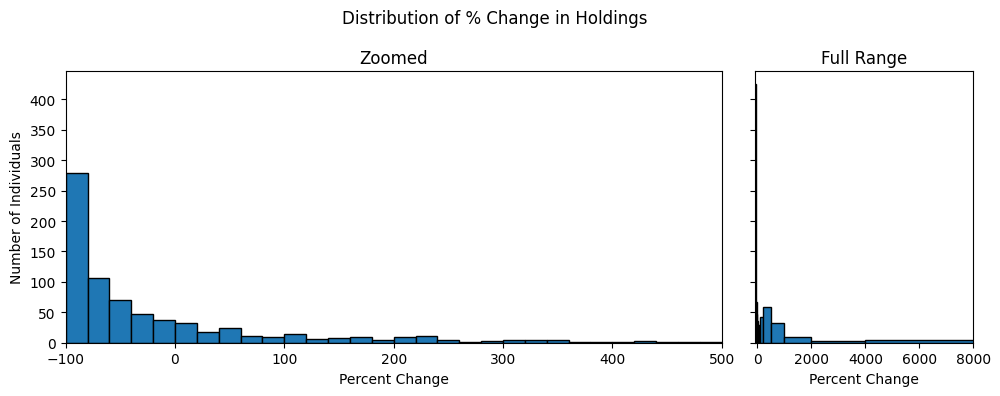

In [170]:
min_percent = combined["percent_change"].min()
max_percent = combined["percent_change"].max()

# create two panels: one full and one zoomed-in
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10,4),
                               gridspec_kw={"width_ratios":[3,1]})

# Main zoomed view
bins_zoom = list(range(int(min_percent), 501, 20))
ax1.hist(combined["percent_change"], bins=bins_zoom, edgecolor='black')
ax1.set_xlim(int(min_percent), 500)
ax1.set_title("Zoomed")
ax1.set_xlabel("Percent Change")

# Full-range view
bins_full = [min_percent,-50,-25,0,25,50,100,200,500,1000,2000,4000,max_percent]
ax2.hist(combined["percent_change"], bins=bins_full, edgecolor='black')
ax2.set_xlim(-100,8000)
ax2.set_title("Full Range")
ax2.set_xlabel("Percent Change")

fig.suptitle("Distribution of % Change in Holdings")
ax1.set_ylabel("Number of Individuals")
plt.tight_layout()
plt.show()

In [171]:
# see outliers
outliers = combined.sort_values(by="percent_change", ascending=False)
print(outliers.head(10))

        recon_id  pre_value  post_value               occupation  \
323  A2297:Z2297        300    24607.93                      NaN   
290  A2176:Z2176        200    15628.78                   Broker   
449  A2957:Z2957        600    38453.05                 Merchant   
39   A1192:Z1192        500    25583.82  Administrator | Esquire   
67   A1319:Z1319        200     9094.72                  Esquire   
117  A1561:Z1561       1300    37942.33                      NaN   
427  A2832:Z2832       1600    34783.82                      NaN   
202  A1871:Z1871        200     4219.00           Excise Officer   
700    A627:Z627        300     4292.81                 Merchant   
658    A424:Z424        200     2781.95                      NaN   

        Group Town  percent_change  
323        Norwich     8102.643333  
290   Philadelphia     7714.390000  
449   Philadelphia     6308.841667  
39    Philadelphia     5016.764000  
67             NaN     4447.360000  
117      Annapolis     2818.6

In [172]:
# convert table to latex
print(outliers.head(10).to_latex())

\begin{tabular}{llrrllr}
\toprule
 & recon_id & pre_value & post_value & occupation & Group Town & percent_change \\
\midrule
323 & A2297:Z2297 & 300 & 24607.930000 & NaN & Norwich & 8102.643333 \\
290 & A2176:Z2176 & 200 & 15628.780000 & Broker & Philadelphia & 7714.390000 \\
449 & A2957:Z2957 & 600 & 38453.050000 & Merchant & Philadelphia & 6308.841667 \\
39 & A1192:Z1192 & 500 & 25583.820000 & Administrator | Esquire & Philadelphia & 5016.764000 \\
67 & A1319:Z1319 & 200 & 9094.720000 & Esquire & NaN & 4447.360000 \\
117 & A1561:Z1561 & 1300 & 37942.330000 & NaN & Annapolis & 2818.640769 \\
427 & A2832:Z2832 & 1600 & 34783.820000 & NaN & Albany Ward 1 & 2073.988750 \\
202 & A1871:Z1871 & 200 & 4219.000000 & Excise Officer & Philadelphia & 2009.500000 \\
700 & A627:Z627 & 300 & 4292.810000 & Merchant & Worcester & 1330.936667 \\
658 & A424:Z424 & 200 & 2781.950000 & NaN & NaN & 1290.975000 \\
\bottomrule
\end{tabular}



In [173]:
# how many doubled their holdings
increased = outliers[outliers["percent_change"] > 100]
count_large = len(increased)
print(count_large / len(combined))

0.1918158567774936


In [174]:
# find average percent change
combined["percent_change"].median()

np.float64(-58.930833333333325)

In [175]:
# find top 5 debtholders in loan office certificates
top5_debtholders = loan_office_certificates.groupby("raw_name_state")["Face Value"].sum().nlargest(5)
print(top5_debtholders)

raw_name_state
JOHN COX||PA            680000
EPHRAIM BLAINE||PA      599800
JOHN JACOB FAISH||PA    483400
ROBERT MORRIS||PA       405700
JESSE TAYLOR||VA        379100
Name: Face Value, dtype: int64


## Geographical Analysis

In [176]:
# get all the matched names
print(len(matched_df) / len(loan_office_certificates))

0.13884048298790058


In [177]:
# get percent of total records in loan_office_certificates
states_total = loan_office_certificates.groupby("state")["raw_name_state"].nunique().sort_values(ascending=False)
pct_states_total = states_total / states_total.sum() * 100
pct_states_total.name = "percent total"
print(pct_states_total)

state
PA    38.813466
MA    15.949227
CT    14.122517
NJ    10.353201
NY     8.040839
MD     5.568433
VA     3.167770
NH     2.930464
DE     1.054084
Name: percent total, dtype: float64


In [178]:
matched_states = matched_df.groupby("state")["recon_id"].nunique().sort_values(ascending=False)
matched_states.head()

state
CT    271
PA    261
MD     86
NY     72
NH     46
Name: recon_id, dtype: int64

In [179]:
# group by state
matched_states.name = "debtholders"
pct = matched_states / matched_states.sum() * 100
pct.name = "percent matched"
matched_states = pd.concat([matched_states, pct, pct_states_total], axis=1)
matched_states.reset_index(inplace=True)
print(matched_states)

  state  debtholders  percent matched  percent total
0    CT          271        34.654731      14.122517
1    PA          261        33.375959      38.813466
2    MD           86        10.997442       5.568433
3    NY           72         9.207161       8.040839
4    NH           46         5.882353       2.930464
5    MA           31         3.964194      15.949227
6    NJ           12         1.534527      10.353201
7    VA            2         0.255754       3.167770
8    DE            1         0.127877       1.054084


In [180]:
latex_str = matched_states.to_latex()
print(latex_str)

\begin{tabular}{llrrr}
\toprule
 & state & debtholders & percent matched & percent total \\
\midrule
0 & CT & 271 & 34.654731 & 14.122517 \\
1 & PA & 261 & 33.375959 & 38.813466 \\
2 & MD & 86 & 10.997442 & 5.568433 \\
3 & NY & 72 & 9.207161 & 8.040839 \\
4 & NH & 46 & 5.882353 & 2.930464 \\
5 & MA & 31 & 3.964194 & 15.949227 \\
6 & NJ & 12 & 1.534527 & 10.353201 \\
7 & VA & 2 & 0.255754 & 3.167770 \\
8 & DE & 1 & 0.127877 & 1.054084 \\
\bottomrule
\end{tabular}



In [181]:
# draw map
fig = px.choropleth(
    matched_states,
    locations='state',                    
    locationmode='USA-states',             
    color='percent matched',              
    scope='usa',                           
    color_continuous_scale='OrRd',         
    labels={'percent matched':'% Matched'},
    title='Percent Matched by State'
)

fig.update_layout(margin=dict(l=10, r=10, t=50, b=10))
fig.show()

## Most Common Occupations

In [182]:
# get all matched individuals in the post-1790 dataset
post_1790_matched = post_1790[post_1790["matched_status"]]
post_1790_matched.head()

,Column,Group Name,state,Group County,Group Town,Group Name Type,Group Match Index,Group Match Url,Full Search Name,assets,...,6p_def_total,unpaid_interest,6p_total_adj,6p_def_total_adj,unpaid_interest_adj,final_total,final_total_adj,recon_id,matched_status,raw_name_state
8,8,Aaron Kelsey,CT,Middlesex County,Killingworth,town,396 | 397,https://www.ancestrylibrary.com/search/collect...,Aaron Kelsey,"CT_445_1 : 63.4, 31.7, 75.62",...,31.70,75.62,63.40,31.70,75.62,95.10,95.10,A10:Z10,True,AARON KELSEY||CT
15,15,Aaron Ogden,NJ,NaN,NaN,state,NaN,https://www.ancestrylibrary.com/search/collect...,Aaron Ogden,"PA_621_1 : 1325.68, 662.85, 714.5",...,662.85,714.50,1325.68,662.85,714.50,1988.53,1988.53,A17:Z17,True,AARON OGDEN||NJ
18,18,Abel Hine,CT,Litchfield County,New Milford,town,302,https://www.ancestrylibrary.com/search/collect...,Abel Hine,"CT_327_1 : 745.65, 372.82, 622.58",...,372.82,622.58,745.65,372.82,622.58,1118.47,1118.47,A20:Z20,True,ABEL HINE||CT
19,19,Abel Morse,CT,Windham County,Woodstock,town,653,https://www.ancestrylibrary.com/search/collect...,Abel Morse,"CT_760_1 : 925.88, 462.95, 666.63",...,462.95,666.63,925.88,462.95,666.63,1388.83,1388.83,A21:Z21,True,ABEL MORSE||CT
20,20,Abel Patchen,CT,Litchfield County,Sharon,town,NaN,https://www.ancestrylibrary.com/search/collect...,Abel Patchen,"CT_137_1 : 102.64, 51.32, 73.9",...,51.32,73.90,102.64,51.32,73.90,153.96,153.96,A22:Z22,True,ABEL PATCHEN||CT


In [183]:
# 1) build the Series of sums (once)
pre_totals = (
    matched_df
      .groupby("recon_id")["Face Value"]
      .sum()
      .rename("pre_1790_total")
)

# 2) on your post-1790 DF, lookup & overwrite that column every time
post_1790_matched["pre_1790_total"] = (
    post_1790_matched["recon_id"]
      .map(pre_totals)    
      .fillna(0)          
)
post_1790_matched.head()

/var/folders/ct/jjmfnk013tn1r7zs75r9b1gw0000gn/T/ipykernel_66312/2055656503.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Column,Group Name,state,Group County,Group Town,Group Name Type,Group Match Index,Group Match Url,Full Search Name,assets,...,unpaid_interest,6p_total_adj,6p_def_total_adj,unpaid_interest_adj,final_total,final_total_adj,recon_id,matched_status,raw_name_state,pre_1790_total
8,8,Aaron Kelsey,CT,Middlesex County,Killingworth,town,396 | 397,https://www.ancestrylibrary.com/search/collect...,Aaron Kelsey,"CT_445_1 : 63.4, 31.7, 75.62",...,75.62,63.40,31.70,75.62,95.10,95.10,A10:Z10,True,AARON KELSEY||CT,200
15,15,Aaron Ogden,NJ,NaN,NaN,state,NaN,https://www.ancestrylibrary.com/search/collect...,Aaron Ogden,"PA_621_1 : 1325.68, 662.85, 714.5",...,714.50,1325.68,662.85,714.50,1988.53,1988.53,A17:Z17,True,AARON OGDEN||NJ,700
18,18,Abel Hine,CT,Litchfield County,New Milford,town,302,https://www.ancestrylibrary.com/search/collect...,Abel Hine,"CT_327_1 : 745.65, 372.82, 622.58",...,622.58,745.65,372.82,622.58,1118.47,1118.47,A20:Z20,True,ABEL HINE||CT,2900
19,19,Abel Morse,CT,Windham County,Woodstock,town,653,https://www.ancestrylibrary.com/search/collect...,Abel Morse,"CT_760_1 : 925.88, 462.95, 666.63",...,666.63,925.88,462.95,666.63,1388.83,1388.83,A21:Z21,True,ABEL MORSE||CT,600
20,20,Abel Patchen,CT,Litchfield County,Sharon,town,NaN,https://www.ancestrylibrary.com/search/collect...,Abel Patchen,"CT_137_1 : 102.64, 51.32, 73.9",...,73.90,102.64,51.32,73.90,153.96,153.96,A22:Z22,True,ABEL PATCHEN||CT,2000


In [184]:
# group by occupation
occupation_counts = post_1790_matched.groupby("occupation").agg(
    count = ("occupation", "size"),
    pre_1790_total = ("pre_1790_total", "sum"),
    post_1790_total = ("final_total_adj", "sum")
).sort_values("count", ascending=False)

# compute the overall sum
total_post1790 = occupation_counts['post_1790_total'].sum()
total_pre1790 = occupation_counts['pre_1790_total'].sum()

# create the percent‐of‐total column
occupation_counts['percent_of_pre1790_total'] = occupation_counts['pre_1790_total'] / total_pre1790 * 100
occupation_counts['percent_of_post1790_total'] = occupation_counts['post_1790_total'] / total_post1790 * 100

print(occupation_counts)


                                  count  pre_1790_total  post_1790_total  \
occupation                                                                 
Farmer                               80          109300       45153.1300   
Esquire                              75          258800      194783.0600   
Merchant                             48          202800      246850.6914   
Widow                                 8            5200        4774.4100   
Esquire | Merchant                    6           45700       65757.2700   
...                                 ...             ...              ...   
Excise Officer                        1             200        4219.0000   
Farmer | School Committee Member      1             700         506.6600   
Administrator | Shopkeeper            1            8100       17722.5000   
Gentlewoman | Widow                   1           28400        6718.0600   
Gardener | Horsestable Owner          1             800          42.1300   

           

In [185]:
# calcualate net change between pre_1790 and post_1790 datasets
occupation_counts["net_pct_change"] = (
    (occupation_counts["post_1790_total"] - occupation_counts["pre_1790_total"])
    / occupation_counts["pre_1790_total"]
    * 100
)
occupation_counts.head()

,count,pre_1790_total,post_1790_total,percent_of_pre1790_total,percent_of_post1790_total,net_pct_change
occupation,,,,,,
Farmer,80,109300,45153.1300,8.950946,4.143686,-58.688811
Esquire,75,258800,194783.0600,21.194005,17.875170,-24.736066
Merchant,48,202800,246850.6914,16.607976,22.653397,21.721248
Widow,8,5200,4774.4100,0.425846,0.438146,-8.184423
Esquire | Merchant,6,45700,65757.2700,3.742527,6.034521,43.888993


In [186]:
print(occupation_counts.head().to_latex())

\begin{tabular}{lrrrrrr}
\toprule
 & count & pre_1790_total & post_1790_total & percent_of_pre1790_total & percent_of_post1790_total & net_pct_change \\
occupation &  &  &  &  &  &  \\
\midrule
Farmer & 80 & 109300 & 45153.130000 & 8.950946 & 4.143686 & -58.688811 \\
Esquire & 75 & 258800 & 194783.060000 & 21.194005 & 17.875170 & -24.736066 \\
Merchant & 48 & 202800 & 246850.691400 & 16.607976 & 22.653397 & 21.721248 \\
Widow & 8 & 5200 & 4774.410000 & 0.425846 & 0.438146 & -8.184423 \\
Esquire | Merchant & 6 & 45700 & 65757.270000 & 3.742527 & 6.034521 & 43.888993 \\
\bottomrule
\end{tabular}



In [187]:
# total number of occupations
print(occupation_counts.sum())

count                        3.430000e+02
pre_1790_total               1.221100e+06
post_1790_total              1.089685e+06
percent_of_pre1790_total     1.000000e+02
percent_of_post1790_total    1.000000e+02
net_pct_change               6.373250e+03
dtype: float64


In [188]:
unique_with_title = loan_office_certificates.loc[loan_office_certificates['raw_title'].notna(), 'raw_name_state'].nunique()
print(f"{unique_with_title} individuals have a title")

# Count total unique individuals
total_individuals = loan_office_certificates['raw_name_state'].nunique()

percent_with_title = unique_with_title / total_individuals * 100
print(f"{percent_with_title:.2f}% of individuals have a title")

1257 individuals have a title
6.94% of individuals have a title


## Ratios

In [189]:
import numpy as np

In [190]:
post_matched = post_1790[post_1790["matched_status"] == True].copy()
print(len(post_matched))

782


In [191]:
# aggregate each person's 6p and def 6p stock
summary = (
    post_matched
    .groupby("recon_id")[["6p_total_adj", "6p_def_total_adj"]]
    .sum()
    .rename(columns={
        "6p_total_adj":      "six_percent_amt",
        "6p_def_total_adj":  "deferred_amt"
    })
)
print(summary.head())

             six_percent_amt  deferred_amt
recon_id                                  
A100:Z100             217.21        108.61
A1016:Z1016           615.28        307.64
A1023:Z1023             0.00          0.00
A1024:Z1024          6265.18       3132.59
A1026:Z1026           274.34        137.16


In [192]:
# compute ratios
summary["post_total"] = summary["six_percent_amt"] + summary["deferred_amt"]
summary["ratio_six"] = summary["six_percent_amt"]  / summary["post_total"]
summary["ratio_deferred"] = summary["deferred_amt"]    / summary["post_total"]
print(summary.head())

             six_percent_amt  deferred_amt  post_total  ratio_six  \
recon_id                                                            
A100:Z100             217.21        108.61      325.82   0.666656   
A1016:Z1016           615.28        307.64      922.92   0.666667   
A1023:Z1023             0.00          0.00        0.00        NaN   
A1024:Z1024          6265.18       3132.59     9397.77   0.666667   
A1026:Z1026           274.34        137.16      411.50   0.666683   

             ratio_deferred  
recon_id                     
A100:Z100          0.333344  
A1016:Z1016        0.333333  
A1023:Z1023             NaN  
A1024:Z1024        0.333333  
A1026:Z1026        0.333317  


In [193]:
# turn pre_totals (type: series) into a dataframe
pre_totals = pre_totals.rename("pre_total").reset_index()
pre_totals.head()


,recon_id,pre_total
0,A100:Z100,1400
1,A1016:Z1016,1400
2,A1023:Z1023,4300
3,A1024:Z1024,1400
4,A1026:Z1026,3200


In [194]:
# add pre_1790 totals
summary = summary.reset_index().merge(
    pre_totals.rename(columns={"Face Value":"pre_total"}),  # or however you named it
    on="recon_id",
    how="left"
)
summary.head()

,recon_id,six_percent_amt,deferred_amt,post_total,ratio_six,ratio_deferred,pre_total
0,A100:Z100,217.21,108.61,325.82,0.666656,0.333344,1400
1,A1016:Z1016,615.28,307.64,922.92,0.666667,0.333333,1400
2,A1023:Z1023,0.00,0.00,0.00,NaN,NaN,4300
3,A1024:Z1024,6265.18,3132.59,9397.77,0.666667,0.333333,1400
4,A1026:Z1026,274.34,137.16,411.50,0.666683,0.333317,3200


In [195]:
# compute expected dollar amounts
EXPECTED_SIX, EXPECTED_DEF = 2/3, 1/3
summary["expected_six_amt"]      = summary["pre_total"] * EXPECTED_SIX
summary["expected_deferred_amt"] = summary["pre_total"] * EXPECTED_DEF
summary.head()

,recon_id,six_percent_amt,deferred_amt,post_total,ratio_six,ratio_deferred,pre_total,expected_six_amt,expected_deferred_amt
0,A100:Z100,217.21,108.61,325.82,0.666656,0.333344,1400,933.333333,466.666667
1,A1016:Z1016,615.28,307.64,922.92,0.666667,0.333333,1400,933.333333,466.666667
2,A1023:Z1023,0.00,0.00,0.00,NaN,NaN,4300,2866.666667,1433.333333
3,A1024:Z1024,6265.18,3132.59,9397.77,0.666667,0.333333,1400,933.333333,466.666667
4,A1026:Z1026,274.34,137.16,411.50,0.666683,0.333317,3200,2133.333333,1066.666667


In [196]:
# flag those within a small tolerance of the ideal 66.67% / 33.33%
tol = 0.005  # ±0.5%
summary["in_ratio_tolerance"] = summary["ratio_six"].between(
    EXPECTED_SIX - tol, EXPECTED_SIX + tol
)
summary.head()

,recon_id,six_percent_amt,deferred_amt,post_total,ratio_six,ratio_deferred,pre_total,expected_six_amt,expected_deferred_amt,in_ratio_tolerance
0,A100:Z100,217.21,108.61,325.82,0.666656,0.333344,1400,933.333333,466.666667,True
1,A1016:Z1016,615.28,307.64,922.92,0.666667,0.333333,1400,933.333333,466.666667,True
2,A1023:Z1023,0.00,0.00,0.00,NaN,NaN,4300,2866.666667,1433.333333,False
3,A1024:Z1024,6265.18,3132.59,9397.77,0.666667,0.333333,1400,933.333333,466.666667,True
4,A1026:Z1026,274.34,137.16,411.50,0.666683,0.333317,3200,2133.333333,1066.666667,True


In [197]:
# quick summary statistics
print(f"Fraction matching within ±{tol*100:.1f}%-points: ",
      summary["in_ratio_tolerance"].mean())
summary.head()

Fraction matching within ±0.5%-points:  0.9028132992327366


,recon_id,six_percent_amt,deferred_amt,post_total,ratio_six,ratio_deferred,pre_total,expected_six_amt,expected_deferred_amt,in_ratio_tolerance
0,A100:Z100,217.21,108.61,325.82,0.666656,0.333344,1400,933.333333,466.666667,True
1,A1016:Z1016,615.28,307.64,922.92,0.666667,0.333333,1400,933.333333,466.666667,True
2,A1023:Z1023,0.00,0.00,0.00,NaN,NaN,4300,2866.666667,1433.333333,False
3,A1024:Z1024,6265.18,3132.59,9397.77,0.666667,0.333333,1400,933.333333,466.666667,True
4,A1026:Z1026,274.34,137.16,411.50,0.666683,0.333317,3200,2133.333333,1066.666667,True


## How Many Names Were Women?

In [198]:
# source: https://www.reddit.com/r/namenerds/comments/v7il84/most_popular_baby_names_in_the_usa_1780/
female_names_1780 = {
    "Mary", "Elizabeth", "Sarah", "Hannah", "Nancy", "Margaret", "Anna",
    "Jane", "Catherine", "Lydia", "Martha", "Ann", "Rebecca", "Abigail",
    "Sally", "Catharine", "Betsey", "Polly", "Lucy", "Rachel", "Susannah",
    "Ruth", "Esther", "Maria", "Phebe", "Susan", "Eunice", "Susanna",
    "Barbara", "Rhoda", "Deborah", "Olive", "Eleanor", "Charlotte",
    "Frances", "Sophia", "Catharina", "Clarissa", "Anne", "Mercy", "Lois",
    "Magdalena", "Dorcas", "Amy", "Betsy", "Cynthia", "Fanny", "Eliza",
    "Charity", "Christina", "Lucinda", "Chloe", "Joanna", "Elisabeth",
    "Alice", "Huldah", "Jemima", "Isabella", "Patience", "Jerusha",
    "Judith", "Mehitable", "Prudence", "Agnes", "Priscilla", "Julia",
    "Ellen", "Dorothy", "Harriet", "Dolly", "Keziah", "Thankful", "Marie",
    "Matilda", "Lucretia", "Temperance", "Tabitha", "Rachael", "Phoebe",
    "Asenath", "Eve", "Salome", "Amelia", "Grace", "Patty", "Persis",
    "Comfort", "Eva", "Hester", "Louisa", "Naomi", "Rebekah", "Bridget",
    "Freelove", "Katherine", "Leah", "Caroline", "Marcy", "Annie", "Azubah"
}

print(len(female_names_1780))

100


In [199]:
def is_female_name(raw_first_name, female_set=female_names_1780):
    """
    Returns True if the given first name (string) appears in the 1780 female names list.
    """
    if not isinstance(raw_first_name, str) or not raw_first_name.strip():
        return False
    # take the first token, strip punctuation, capitalize
    first = raw_first_name.strip().split()[0].strip(".,").capitalize()
    return first in female_set

In [200]:
# extract first name, reformat, and check if it is in female names list
loan_office_certificates_copy = loan_office_certificates.copy()
print("before dropping duplicates: " + str(len(loan_office_certificates_copy)))
loan_office_certificates_copy = loan_office_certificates_copy.drop_duplicates(subset="raw_name_state")
loan_office_certificates_copy["is_female"] = loan_office_certificates_copy["raw_first_name_1"].apply(is_female_name)
print("after dropping duplicates: " + str(len(loan_office_certificates_copy)))
loan_office_certificates_copy.head()

before dropping duplicates: 80913
after dropping duplicates: 18121


,state,Year,Month,Day,raw_title,raw_first_name_1,raw_last_name_1,raw_name,raw_name_state,matched_status,last_name_state,last_name_matched_status,is_entity,recon_id,raw_first_name_2,raw_last_name_2,raw_name_2,Face Value,Specie Value,is_female
0,NH,1778,3,13.0,COL,JOSHUA,WENTWORTH,JOSHUA WENTWORTH,JOSHUA WENTWORTH||NH,False,WENTWORTH||NH,False,False,NaN,NAN,NAN,NAN NAN,200,108.2778,False
1,NH,1777,9,2.0,NaN,CHARLES,TREADWELL,CHARLES TREADWELL,CHARLES TREADWELL||NH,False,TREADWELL||NH,True,False,NaN,NaN,NaN,NaN,200,199.3778,False
2,NH,1777,9,10.0,NaN,STEPHEN,CLEVERLY,STEPHEN CLEVERLY,STEPHEN CLEVERLY||NH,False,CLEVERLY||NH,False,False,NaN,NaN,NaN,NaN,200,194.5111,False
3,NH,1777,9,13.0,NaN,DAVID,GRIFFITH,DAVID GRIFFITH,DAVID GRIFFITH||NH,False,GRIFFITH||NH,False,False,NaN,NaN,NaN,NaN,200,192.7111,False
4,NH,1777,9,15.0,NaN,JOHN,MANSFIELD,JOHN MANSFIELD,JOHN MANSFIELD||NH,False,MANSFIELD||NH,False,False,NaN,NaN,NaN,NaN,200,191.5222,False


In [201]:
# compute percent women
pct_women_loan_office = loan_office_certificates_copy["is_female"].mean() * 100
print(f"{pct_women_loan_office:.2f}% of unique loan office certificate debtholders were likely women")

7.29% of unique loan office certificate debtholders were likely women


In [202]:
# do the same for liquidated debt certificates
liquidated_debt_certificates = pd.read_csv("liquidated_debt_certificates.csv")
liquidated_debt_certificates.rename(columns={'uid': 'raw_name_state'}, inplace=True)
print("before dropping duplicates: " + str(len(liquidated_debt_certificates)))
liquidated_debt_certificates = liquidated_debt_certificates.drop_duplicates(subset="raw_name_state")
liquidated_debt_certificates["is_female"] = liquidated_debt_certificates["raw_first_name_1"].apply(is_female_name)
print("after dropping duplicates: " + str(len(liquidated_debt_certificates)))
liquidated_debt_certificates.head()

before dropping duplicates: 28853
after dropping duplicates: 20117


/var/folders/ct/jjmfnk013tn1r7zs75r9b1gw0000gn/T/ipykernel_66312/132029749.py:2: DtypeWarning:

Columns (2,4,5,6,11,14,15,16,19,20,21,22,24,25,30,34,35,36,40,41,42,82,83,85,86,87,89,90,91,92,122,128,129,130,131,137,138,141,142) have mixed types. Specify dtype option on import or set low_memory=False.



,Archive,File,Register Page,state,JPEG number,Number,Letter,Date of the Certificate Month,Day,Year,...,exchange,amt_specie_1,amt_specie_2,To whom due First name 2,w Dollars,8th,Delivered Month,Day3,Year3,is_female
0,Archive.zip,ct.csv,4,CT,256,1.0,A,6.0,28.0,1783.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,Archive.zip,ct.csv,4,CT,256,2.0,B,6.0,30.0,1783.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,Archive.zip,ct.csv,4,CT,256,3.0,C,7.0,1.0,1783.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,Archive.zip,ct.csv,4,CT,256,4.0,D,7.0,2.0,1783.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,Archive.zip,ct.csv,4,CT,256,5.0,E,7.0,3.0,1783.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [203]:
# compute percent women
pct_women_liquidated = liquidated_debt_certificates["is_female"].mean() * 100
print(f"{pct_women_liquidated:.2f}% of unique liquidated debt certificate debtholders were likely women")

1.19% of unique liquidated debt certificate debtholders were likely women


In [204]:
# do the same for pierce certificates (we expect 0)
pierce_certificates = pd.read_csv("pierce_certificates.csv")
print("before dropping duplicates: " + str(len(pierce_certificates)))
pierce_certificates = pierce_certificates.drop_duplicates(subset="raw_name_state")
pierce_certificates["is_female"] = pierce_certificates["raw_first_name_1"].apply(is_female_name)
print("after dropping duplicates: " + str(len(pierce_certificates)))

print(pierce_certificates[pierce_certificates["is_female"]].head())
# compute percent women
pct_women_pierce = pierce_certificates["is_female"].mean() * 100
print(f"{pct_women_pierce:.2f}% of unique pierce certificate debtholders were likely women")

before dropping duplicates: 93311
after dropping duplicates: 36330
            CN raw_first_name_1 raw_last_name_1         raw_name  \
5213    3244.0          COMFORT           BEBEE    COMFORT BEBEE   
5317    2366.0          COMFORT          BEEBEE   COMFORT BEEBEE   
14056  14748.0          COMFORT         CHAFFEE  COMFORT CHAFFEE   
14391   2572.0          COMFORT         CHAPMAN  COMFORT CHAPMAN   
14392   3424.0          COMFORT         CHAPMAN  COMFORT CHAPMAN   

            raw_name_state  Value  Group  \
5213     COMFORT BEBEE||CT  80.00   13.0   
5317    COMFORT BEEBEE||PA  20.70   12.0   
14056  COMFORT CHAFFEE||MA  10.58   24.0   
14391  COMFORT CHAPMAN||PA  21.84   12.0   
14392  COMFORT CHAPMAN||CT  56.80   13.0   

                                          To Whom Issued state  Officer  \
5213   Ebenezer Huntington's Connecticut Regiment  pa...    CT      0.0   
5317   Regiment of Capt. Bartholomew Van Heers  paid ...    PA      0.0   
14056  Fourth Regiment (old Ninth)

In [205]:
def extract_first_name(full_name):
    first = full_name.strip().split()[0]
    return first.strip(".,").capitalize()

In [206]:
# do the same for the post-1790 dataset
post_1790 = pd.read_csv("post_1790.csv")
post_1790["first_name"] = post_1790["Group Name"].apply(extract_first_name)
print(post_1790["first_name"].head())


post_1790["is_female"] = post_1790["first_name"].apply(is_female_name)
print(post_1790[post_1790["is_female"]].head())

# compute percent women
pct_women_post_1790 = post_1790["is_female"].mean() * 100
print(f"{pct_women_post_1790:.2f}% of unique post-1790 debtholders were likely women")


0    Desdeily
1       Grund
2       Aaron
3       Aaron
4       Aaron
Name: first_name, dtype: object
    Column         Group Name state         Group County    Group Town  \
27      27        Abigail Ash    PA  Philadelphia County  Philadelphia   
28      28       Abigail Ball    NH    Rockingham County    Portsmouth   
29      29    Abigail Bulkley    CT    New London County    Colchester   
30      30  Abigail Ellsworth    CT      Hartford County       Windsor   
31      31      Abigail Keyes    CT      Hartford County      Hartford   

   Group Name Type Group Match Index  \
27            town              1349   
28            town               NaN   
29            town               NaN   
30            town               488   
31            town               NaN   

                                      Group Match Url  \
27  https://www.ancestrylibrary.com/search/collect...   
28  https://www.ancestrylibrary.com/search/collect...   
29  https://www.ancestrylibrary.com/searc

In [207]:
pierce_certificates.sample(10)[["raw_name_state","is_female"]]

,raw_name_state,is_female
51350,RICHARD LOUDON||PA,False
37176,JOHN HARRIS||PA,False
52475,EDWARD MAILY||PA,False
72026,JESSE ROYAL||DE,False
52963,JACOB MARIUS||NY,False
69561,PRINCE RHODES||RI,False
12396,JOHN CALDWELL||NH,False
65218,JOSEPH PETTINGILL||MA,False
71405,DANIEL ROLO||CT,False
33938,FRAZIER GRAY||DE,False


## Ambiguous Matches: Matches That Need More Location Information

In [208]:
post_1790_matched.head()

,Column,Group Name,state,Group County,Group Town,Group Name Type,Group Match Index,Group Match Url,Full Search Name,assets,...,unpaid_interest,6p_total_adj,6p_def_total_adj,unpaid_interest_adj,final_total,final_total_adj,recon_id,matched_status,raw_name_state,pre_1790_total
8,8,Aaron Kelsey,CT,Middlesex County,Killingworth,town,396 | 397,https://www.ancestrylibrary.com/search/collect...,Aaron Kelsey,"CT_445_1 : 63.4, 31.7, 75.62",...,75.62,63.40,31.70,75.62,95.10,95.10,A10:Z10,True,AARON KELSEY||CT,200
15,15,Aaron Ogden,NJ,NaN,NaN,state,NaN,https://www.ancestrylibrary.com/search/collect...,Aaron Ogden,"PA_621_1 : 1325.68, 662.85, 714.5",...,714.50,1325.68,662.85,714.50,1988.53,1988.53,A17:Z17,True,AARON OGDEN||NJ,700
18,18,Abel Hine,CT,Litchfield County,New Milford,town,302,https://www.ancestrylibrary.com/search/collect...,Abel Hine,"CT_327_1 : 745.65, 372.82, 622.58",...,622.58,745.65,372.82,622.58,1118.47,1118.47,A20:Z20,True,ABEL HINE||CT,2900
19,19,Abel Morse,CT,Windham County,Woodstock,town,653,https://www.ancestrylibrary.com/search/collect...,Abel Morse,"CT_760_1 : 925.88, 462.95, 666.63",...,666.63,925.88,462.95,666.63,1388.83,1388.83,A21:Z21,True,ABEL MORSE||CT,600
20,20,Abel Patchen,CT,Litchfield County,Sharon,town,NaN,https://www.ancestrylibrary.com/search/collect...,Abel Patchen,"CT_137_1 : 102.64, 51.32, 73.9",...,73.90,102.64,51.32,73.90,153.96,153.96,A22:Z22,True,ABEL PATCHEN||CT,2000


In [209]:
loan_office_certificates.head()

,state,Year,Month,Day,raw_title,raw_first_name_1,raw_last_name_1,raw_name,raw_name_state,matched_status,last_name_state,last_name_matched_status,is_entity,recon_id,raw_first_name_2,raw_last_name_2,raw_name_2,Face Value,Specie Value
0,NH,1778,3,13.0,COL,JOSHUA,WENTWORTH,JOSHUA WENTWORTH,JOSHUA WENTWORTH||NH,False,WENTWORTH||NH,False,False,NaN,NAN,NAN,NAN NAN,200,108.2778
1,NH,1777,9,2.0,NaN,CHARLES,TREADWELL,CHARLES TREADWELL,CHARLES TREADWELL||NH,False,TREADWELL||NH,True,False,NaN,NaN,NaN,NaN,200,199.3778
2,NH,1777,9,10.0,NaN,STEPHEN,CLEVERLY,STEPHEN CLEVERLY,STEPHEN CLEVERLY||NH,False,CLEVERLY||NH,False,False,NaN,NaN,NaN,NaN,200,194.5111
3,NH,1777,9,13.0,NaN,DAVID,GRIFFITH,DAVID GRIFFITH,DAVID GRIFFITH||NH,False,GRIFFITH||NH,False,False,NaN,NaN,NaN,NaN,200,192.7111
4,NH,1777,9,15.0,NaN,JOHN,MANSFIELD,JOHN MANSFIELD,JOHN MANSFIELD||NH,False,MANSFIELD||NH,False,False,NaN,NaN,NaN,NaN,200,191.5222


In [210]:
# Dedupe pre-1790 down to one row per person+state
unique_pre = loan_office_certificates.drop_duplicates(subset="raw_name_state")

# count how many records there are *per* name+state
post_counts = (
    post_1790_matched
      .groupby("raw_name_state")
      .size()
      .reset_index(name="post_count")
)


# Left-join those counts back into unique_pre
merged = unique_pre.merge(post_counts, on="raw_name_state", how="left")

total = len(unique_pre)

# How many have *no* post-1790 match at all?
no_match = (merged["post_count"].fillna(0) == 0).sum()

# How many have *exactly one* post-1790 match?
exactly_one = (merged["post_count"] == 1).sum()

# How many have *more than one* post-1790 match (i.e. ambiguous)?
ambiguous = (merged["post_count"] > 1).sum()

print(f"Total pre-1790 records:        {total}")
print(f"No post-1790 match:            {no_match} ({no_match/total:.1%})")
print(f"Exactly one post-1790 match:   {exactly_one} ({exactly_one/total:.1%})")
print(f"Ambiguous (>1 match):          {ambiguous} ({ambiguous/total:.1%})")

Total pre-1790 records:        18121
No post-1790 match:            17339 (95.7%)
Exactly one post-1790 match:   782 (4.3%)
Ambiguous (>1 match):          0 (0.0%)


## Reconciling on Last Name and State Only

In [211]:
# record-level coverage:
total_records = len(loan_office_certificates)
matched_records = loan_office_certificates["last_name_matched_status"].sum()
record_level_rate = matched_records / total_records * 100
print(f"Record-level match rate: {record_level_rate:.1f}% ({matched_records}/{total_records})") 

Record-level match rate: 35.1% (28422/80913)


In [212]:
# distinct-key coverage:
# first collapse to one row per last_name_state
keys = loan_office_certificates.drop_duplicates(subset="last_name_state")
total_keys = len(keys)
matched_keys = keys["last_name_matched_status"].sum()
key_level_rate = matched_keys / total_keys * 100
print(f"Distinct-key match rate: {key_level_rate:.1f}% ({matched_keys}/{total_keys})")

Distinct-key match rate: 10.4% (1123/10754)


In [ ]:
# record‐level match rate:
total_records = len(loan_office_certificates)
matched_records = loan_office_certificates['matched_status'].sum()  # assuming True/False or 1/0
record_match_rate = matched_records / total_records * 100

print(f"Record‐level match rate: {record_match_rate:.2f}% "
      f"({matched_records}/{total_records})")

Record‐level match rate: 13.88% (11234/80913)


In [215]:
# distinct‐key match rate on raw_name_state:
unique_keys    = loan_office_certificates.drop_duplicates(subset='raw_name_state')
total_keys     = len(unique_keys)
matched_keys   = unique_keys['matched_status'].sum()
key_match_rate = matched_keys / total_keys * 100

print(f"Distinct-key match rate: {key_match_rate:.2f}% "
      f"({matched_keys}/{total_keys})")

Distinct-key match rate: 4.32% (782/18121)
